   PropertyID     Location  Size_sqft  SalePrice
0        2001       Suburb       2996     355372
1        2002     Downtown       2887     505830
2        2003       Suburb        957     338789
3        2004  Countryside       1814     419335
4        2005       Suburb        850     357301
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   PropertyID  100 non-null    int64 
 1   Location    100 non-null    object
 2   Size_sqft   100 non-null    int64 
 3   SalePrice   100 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 3.3+ KB
None
        PropertyID    Size_sqft      SalePrice
count   100.000000   100.000000     100.000000
mean   2050.500000  1832.410000  401866.300000
std      29.011492   695.535926  116274.958848
min    2001.000000   806.000000  205943.000000
25%    2025.750000  1154.000000  303015.500000
50%    2050.500000  1816.0

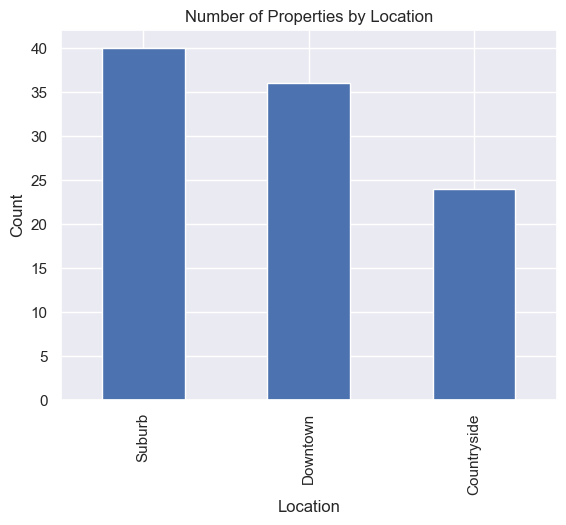

Location
Countryside    421516.958333
Suburb         417716.400000
Downtown       371154.638889
Name: SalePrice, dtype: float64


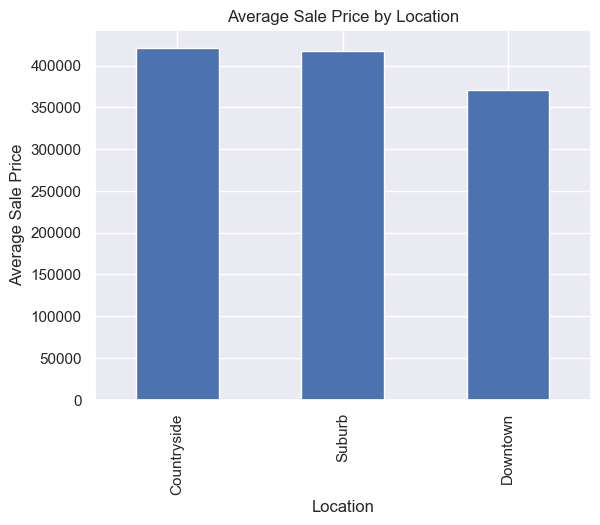

Location
Downtown       1888.111111
Suburb         1847.250000
Countryside    1724.125000
Name: Size_sqft, dtype: float64


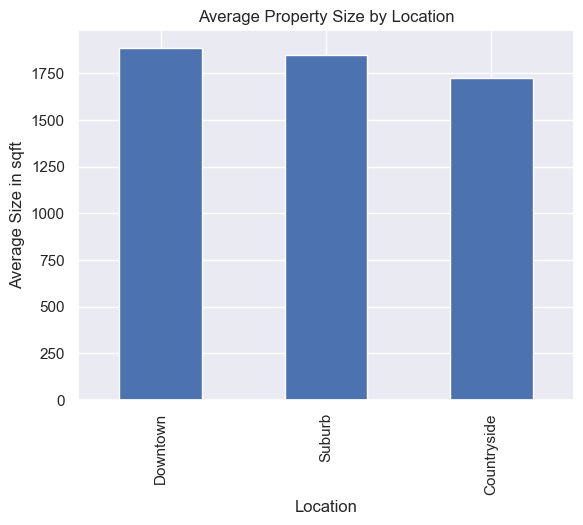

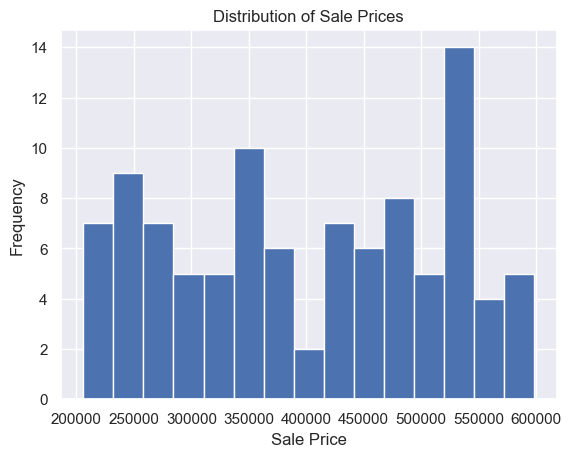

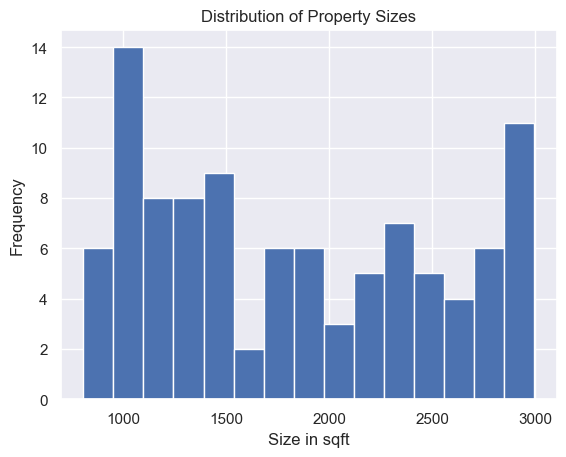

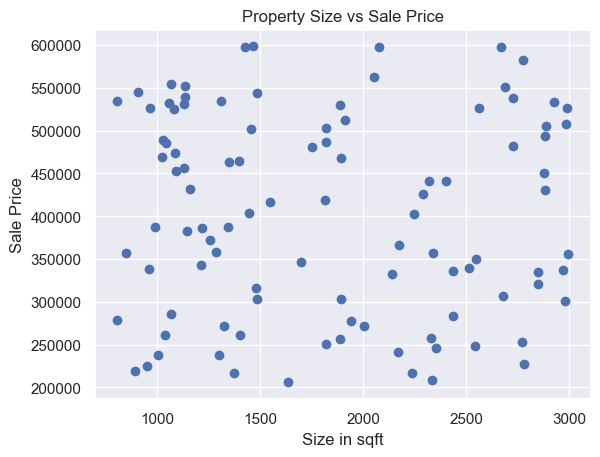

           Size_sqft  SalePrice
Size_sqft   1.000000  -0.030733
SalePrice  -0.030733   1.000000
Location
Countryside    276.926586
Suburb         270.631087
Downtown       228.975177
Name: Price_per_sqft, dtype: float64
    PropertyID     Location  Size_sqft  SalePrice  Price_per_sqft
20        2021  Countryside       1464     598378      408.728142
44        2045       Suburb       2078     597655      287.610683
65        2066     Downtown       1426     597383      418.922160
79        2080       Suburb       2671     597351      223.643205
39        2040       Suburb       2775     582544      209.925766
99        2100  Countryside       2050     562155      274.221951
61        2062       Suburb       1064     554789      521.418233
92        2093       Suburb       1136     551525      485.497359
96        2097       Suburb       2686     551317      205.255771
83        2084  Countryside        907     544991      600.872106
    PropertyID     Location  Size_sqft  SalePrice  Pri

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

df = pd.read_csv("properties.csv")

# Basic overview
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

# Count properties by location
print(df["Location"].value_counts())

df["Location"].value_counts().plot(kind="bar")
plt.title("Number of Properties by Location")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()

# Average sale price by location
avg_price = df.groupby("Location")["SalePrice"].mean().sort_values(ascending=False)
print(avg_price)

avg_price.plot(kind="bar")
plt.title("Average Sale Price by Location")
plt.xlabel("Location")
plt.ylabel("Average Sale Price")
plt.show()

# Average size by location
avg_size = df.groupby("Location")["Size_sqft"].mean().sort_values(ascending=False)
print(avg_size)

avg_size.plot(kind="bar")
plt.title("Average Property Size by Location")
plt.xlabel("Location")
plt.ylabel("Average Size in sqft")
plt.show()

# Sale price distribution
df["SalePrice"].plot(kind="hist", bins=15)
plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.show()

# Size distribution
df["Size_sqft"].plot(kind="hist", bins=15)
plt.title("Distribution of Property Sizes")
plt.xlabel("Size in sqft")
plt.show()

# Size vs sale price
plt.scatter(df["Size_sqft"], df["SalePrice"])
plt.title("Property Size vs Sale Price")
plt.xlabel("Size in sqft")
plt.ylabel("Sale Price")
plt.show()

# Correlation
print(df[["Size_sqft", "SalePrice"]].corr())

# Price per square foot
df["Price_per_sqft"] = df["SalePrice"] / df["Size_sqft"]

print(df.groupby("Location")["Price_per_sqft"].mean().sort_values(ascending=False))

# Top 10 most expensive properties
print(df.sort_values("SalePrice", ascending=False).head(10))

# Top 10 cheapest properties
print(df.sort_values("SalePrice").head(10))